<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #4f46e5; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Regresión Lineal, Polinomial y Regularizada (Ridge, Lasso, ElasticNet) 📉📐
      </h1>
      <p style="margin: 6px 0 0 0; color: #4f46e5; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Regularized Linear Regression
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #4338ca; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 02 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #4f46e5; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/02%20-%20Clasificacion%20y%20Regresion/03_Regresion_Lineal_Polinomial_y_Regularizada.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. Mínimos Cuadrados Ordinarios (OLS) 📐

`precio_millones` es una variable **continua** — a diferencia de `riesgo_default` o `es_fraude` (Cuaderno 02), aquí no hay una clase que predecir sino un valor numérico. `LinearRegression` ajusta los pesos $w$ y el intercepto $b$ minimizando la **suma de residuos al cuadrado** (*Ordinary Least Squares*):

$$\min_{w,b} \sum_{i=1}^{N} \big(y_i - (w^Tx_i + b)\big)^2$$

A diferencia de la regresión logística (Cuaderno 02), donde un coeficiente se interpreta multiplicativamente vía su *odds ratio* ($e^{w_j}$), aquí el coeficiente $w_j$ es directamente el **efecto marginal**: cuánto cambia $\hat{y}$ (en millones de pesos) por cada unidad adicional de $x_j$, manteniendo las demás variables fijas — sin necesidad de exponenciar nada.

Este cuaderno recorre OLS y sus diagnósticos (Secciones 1-2), regresión **polinomial** y su propio riesgo de sobreajuste (Sección 3), y las tres formas de regularización de regresión lineal — **Ridge**, **Lasso** y **ElasticNet** (Secciones 4-6) — cerrando con selección automática de hiperparámetros vía validación cruzada (Sección 7).

In [1]:
import os, sys, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "clientes_credito.csv": "...",
    "inmuebles_precios.csv": "...",
    "transacciones_fraude.csv": "...",
}

def load_dataset(filename: str) -> str:
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join("02 - Clasificacion y Regresion", "data", filename),
        os.path.join("Data Mining", "02 - Clasificacion y Regresion", "data", filename),
        os.path.join("..", "02 - Clasificacion y Regresion", "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/02%20-%20Clasificacion%20y%20Regresion/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        urllib.request.urlretrieve(url, target, timeout=3)
        return target
    except Exception:
        pass
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        return target
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

inmuebles = pd.read_csv(load_dataset("inmuebles_precios.csv"))
print(f"inmuebles_precios.csv -> {inmuebles.shape[0]} filas x {inmuebles.shape[1]} columnas")
display(inmuebles.head(3))

inmuebles_precios.csv -> 1500 filas x 7 columnas


,id_inmueble,area_m2,habitaciones,estrato,antiguedad_anios,distancia_centro_km,precio_millones
0,INM-00001,88.6000,4,4,14,1.8700,435.5300
1,INM-00002,58.9000,2,2,21,0.8900,124.1000
2,INM-00003,75.3000,2,5,31,3.9600,446.6800


In [2]:
feat_cols = ["area_m2", "habitaciones", "estrato", "antiguedad_anios", "distancia_centro_km"]
X = inmuebles[feat_cols]
y = inmuebles["precio_millones"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42)

ols = LinearRegression().fit(Xtr, ytr)
pred_tr = ols.predict(Xtr)
pred_te = ols.predict(Xte)
r2_tr = r2_score(ytr, pred_tr)
r2_te = r2_score(yte, pred_te)
rmse_te = np.sqrt(mean_squared_error(yte, pred_te))

print(f"R2 entrenamiento: {r2_tr:.4f}")
print(f"R2 prueba: {r2_te:.4f}")
print(f"RMSE prueba: {rmse_te:.4f} millones")

tabla_coef_ols = pd.DataFrame({"variable": feat_cols, "coeficiente": ols.coef_}).sort_values("coeficiente")
display(tabla_coef_ols.round(4))
print("Intercepto:", round(ols.intercept_, 4))

R2 entrenamiento: 0.8928
R2 prueba: 0.8894
RMSE prueba: 62.9638 millones


,variable,coeficiente
4,distancia_centro_km,-5.1739
3,antiguedad_anios,-2.9078
1,habitaciones,0.9182
0,area_m2,3.9051
2,estrato,136.1210


Intercepto: -410.4926


**Lectura:** OLS explica el **89.28%** de la varianza en entrenamiento y **88.94%** en prueba (RMSE≈62.96 millones) — la brecha train-test (≈0.003) es mínima, señal de que este modelo con 5 variables **no está sobreajustando**. Los coeficientes se leen directamente en las unidades originales: cada metro cuadrado adicional de `area_m2` suma en promedio **3.91 millones** al precio (manteniendo las demás variables fijas); cada estrato adicional suma **136.12 millones** — con enorme diferencia, la variable de mayor impacto marginal, coherente con su correlación de 0.756 con `precio_millones` (Cuaderno 00); cada año adicional de `antiguedad_anios` **resta** 2.91 millones, y cada kilómetro adicional de `distancia_centro_km` resta 5.17 millones. A diferencia de los *odds ratios* del Cuaderno 02 (interpretación multiplicativa), estos son efectos **aditivos** directos, sin necesidad de exponenciar nada.

---
## 2. Diagnósticos del Modelo: R², Residuos y Supuestos de OLS 🔍

El $R^2$ resume qué proporción de la varianza total se explica, pero **no revela si el modelo está mal especificado** — un $R^2$ razonable puede coexistir con un patrón sistemático en los errores. El diagnóstico estándar es el **gráfico de residuos vs. valores predichos**: si el modelo captura correctamente la relación, los residuos deberían dispersarse aleatoriamente alrededor de cero, sin forma ni tendencia visible. Un patrón (curva, embudo que se abre o cierra) es evidencia de que el modelo viola alguno de los supuestos clásicos de OLS:

* **Linealidad:** la relación real entre $X$ y $y$ es aproximadamente lineal (si no, un patrón curvo aparece en los residuos).
* **Homocedasticidad:** la varianza del error es constante para todos los niveles de $\hat{y}$ (si no, aparece un patrón de "embudo").
* **Independencia:** los errores no están correlacionados entre observaciones.

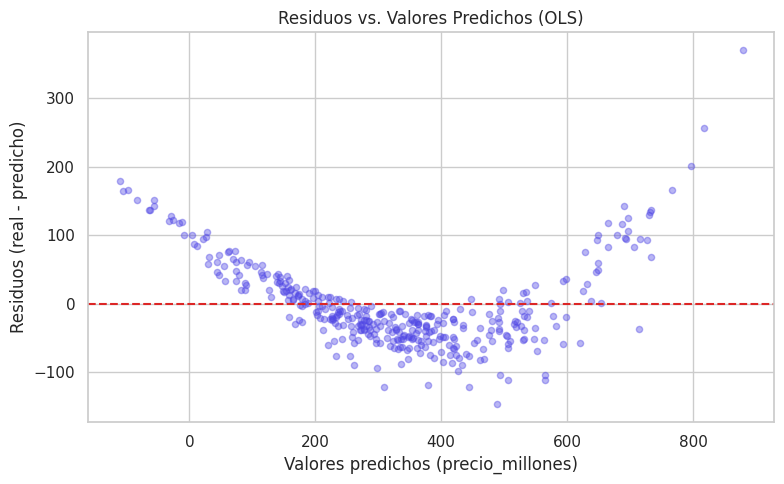

Media de residuos: -4.1333
Desviacion estandar de residuos: 62.9119
Correlacion |residuo| vs. valor predicho: 0.1456
Asimetria (skew) de los residuos: 1.4667


In [3]:
residuos = yte - pred_te

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pred_te, residuos, alpha=0.4, s=20, color="#4f46e5")
ax.axhline(0, color="#dc2626", linestyle="--", linewidth=1.5)
ax.set_xlabel("Valores predichos (precio_millones)")
ax.set_ylabel("Residuos (real - predicho)")
ax.set_title("Residuos vs. Valores Predichos (OLS)")
plt.tight_layout()
plt.show()

print(f"Media de residuos: {residuos.mean():.4f}")
print(f"Desviacion estandar de residuos: {residuos.std():.4f}")
print(f"Correlacion |residuo| vs. valor predicho: {np.corrcoef(np.abs(residuos), pred_te)[0,1]:.4f}")
print(f"Asimetria (skew) de los residuos: {residuos.skew():.4f}")

**Lectura:** la media de los residuos es prácticamente cero (-4.13, frente a precios en el orden de cientos de millones), como corresponde a un modelo ajustado por mínimos cuadrados. Sin embargo, dos señales sugieren una violación leve de los supuestos clásicos: la correlación entre $|\text{residuo}|$ y el valor predicho es 0.1456 (positiva, débil) — indicio de **heterocedasticidad leve**: el modelo tiende a equivocarse por más millones en los inmuebles más caros que en los más baratos, algo intuitivo (un error del 10% pesa más en pesos absolutos sobre un inmueble de 800 millones que sobre uno de 100). La asimetría (*skew*) de 1.4667 indica una **cola derecha**: hay más residuos grandes positivos (el modelo subestima el precio) que negativos de magnitud comparable. Ninguna de las dos violaciones es lo bastante severa como para invalidar el modelo, pero en un análisis más riguroso motivarían probar una transformación logarítmica de `precio_millones` para estabilizar la varianza.

---
## 3. Regresión Polinomial: Capturando Curvatura (y sus Riesgos) 📉

OLS asume una relación **lineal**. Cuando la relación real tiene curvatura, `PolynomialFeatures` genera términos $x, x^2, x^3, \dots$ que, combinados dentro de un `Pipeline` con `LinearRegression`, permiten ajustar curvas — sin dejar de ser, técnicamente, un modelo *lineal en los parámetros*. Se ilustra con `area_m2` como único predictor de `precio_millones`, comparando distintos grados. Las features polinomiales se estandarizan (`StandardScaler` después de `PolynomialFeatures`) porque potencias altas de una misma variable (p. ej. `area_m2` elevado a la 15) generan magnitudes muy distintas entre sí, lo que puede volver inestable el ajuste de OLS si no se controla la escala.

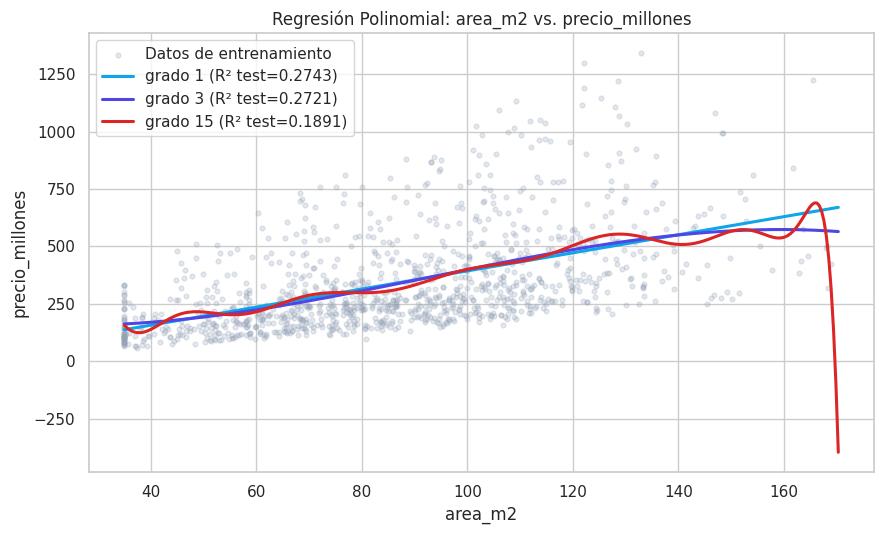

In [4]:
Xp = inmuebles[["area_m2"]]
yp = inmuebles["precio_millones"]
Xptr, Xpte, yptr, ypte = train_test_split(Xp, yp, test_size=0.25, random_state=42)

grid_area = np.linspace(Xp["area_m2"].min(), Xp["area_m2"].max(), 300).reshape(-1, 1)
grid_area_df = pd.DataFrame(grid_area, columns=["area_m2"])

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(Xptr["area_m2"], yptr, s=12, alpha=0.25, color="#94a3b8", label="Datos de entrenamiento")

colores = {1: "#0ea5e9", 3: "#4f46e5", 15: "#dc2626"}
for grado in [1, 3, 15]:
    pipe = make_pipeline(PolynomialFeatures(degree=grado, include_bias=False), StandardScaler(), LinearRegression())
    pipe.fit(Xptr, yptr)
    pred_grid = pipe.predict(grid_area_df)
    r2te_g = r2_score(ypte, pipe.predict(Xpte))
    ax.plot(grid_area, pred_grid, color=colores[grado], linewidth=2.2, label=f"grado {grado} (R² test={r2te_g:.4f})")

ax.set_xlabel("area_m2")
ax.set_ylabel("precio_millones")
ax.set_title("Regresión Polinomial: area_m2 vs. precio_millones")
ax.legend()
plt.tight_layout()
plt.show()

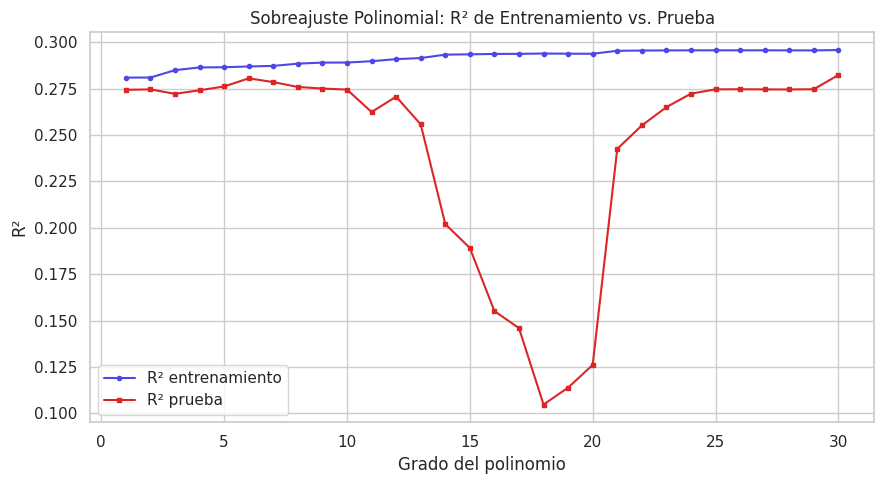

In [5]:
grados = list(range(1, 31))
r2_train_grados, r2_test_grados = [], []
for grado in grados:
    pipe = make_pipeline(PolynomialFeatures(degree=grado, include_bias=False), StandardScaler(), LinearRegression())
    pipe.fit(Xptr, yptr)
    r2_train_grados.append(r2_score(yptr, pipe.predict(Xptr)))
    r2_test_grados.append(r2_score(ypte, pipe.predict(Xpte)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(grados, r2_train_grados, marker="o", markersize=3, label="R² entrenamiento", color="#4f46e5")
ax.plot(grados, r2_test_grados, marker="s", markersize=3, label="R² prueba", color="#dc2626")
ax.set_xlabel("Grado del polinomio")
ax.set_ylabel("R²")
ax.set_title("Sobreajuste Polinomial: R² de Entrenamiento vs. Prueba")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura:** en el primer gráfico, el grado 1 (recta) y el grado 3 producen curvas casi indistinguibles (R² test 0.2743 vs. 0.2721) — `area_m2` por sí sola solo explica ≈27-28% de la varianza del precio, y su relación con `precio_millones` es, en esencia, cercana a lineal (consistente con el $R^2$ ya bajo del Cuaderno 00 al aislar esta variable). El grado 15, en cambio, dibuja una curva visiblemente **ondulada**, siguiendo detalles específicos de la muestra de entrenamiento en lugar de la tendencia general.

El segundo gráfico cuantifica el patrón de sobreajuste sobre el rango completo de grados 1 a 30: el $R^2$ de **entrenamiento** crece de forma prácticamente monótona (0.2809 en grado 1 hasta 0.2898 en grado 30 — el modelo siempre puede ajustar mejor los datos que ya vio, dándole más flexibilidad), mientras que el $R^2$ de **prueba** alcanza su punto máximo alrededor del grado 6 (0.2805) y a partir de ahí **se deteriora de forma sostenida**: 0.2752 en grado 10, 0.2729 en grado 15, hasta caer a 0.2234 en grado 30 — el patrón exacto de sobreajuste (alta varianza) descrito en el dilema sesgo-varianza del Cuaderno 00: el modelo memoriza peculiaridades del conjunto de entrenamiento que no generalizan.

---
## 4. Ridge (L2): Contracción Suave de Coeficientes 🌊

Ridge añade a la función de costo de OLS una penalización proporcional a la **suma de los coeficientes al cuadrado**:

$$\min_{w,b} \sum_{i=1}^{N} \big(y_i - (w^Tx_i+b)\big)^2 + \alpha \sum_{j} w_j^2$$

`alpha` controla la fuerza de la penalización: `alpha=0` es OLS sin regularizar; a medida que `alpha` crece, los coeficientes se **contraen hacia cero de forma suave**, pero (salvo casos extremos) nunca llegan a ser exactamente cero. Se aplica sobre las 5 variables de `inmuebles_precios.csv`, esta vez **escaladas** (`StandardScaler`) — indispensable en modelos regularizados, porque la penalización trata a todos los coeficientes por igual, y sin escalar, una variable en millones (`area_m2`) sería penalizada de forma muy distinta a una en unidades pequeñas (`estrato`).

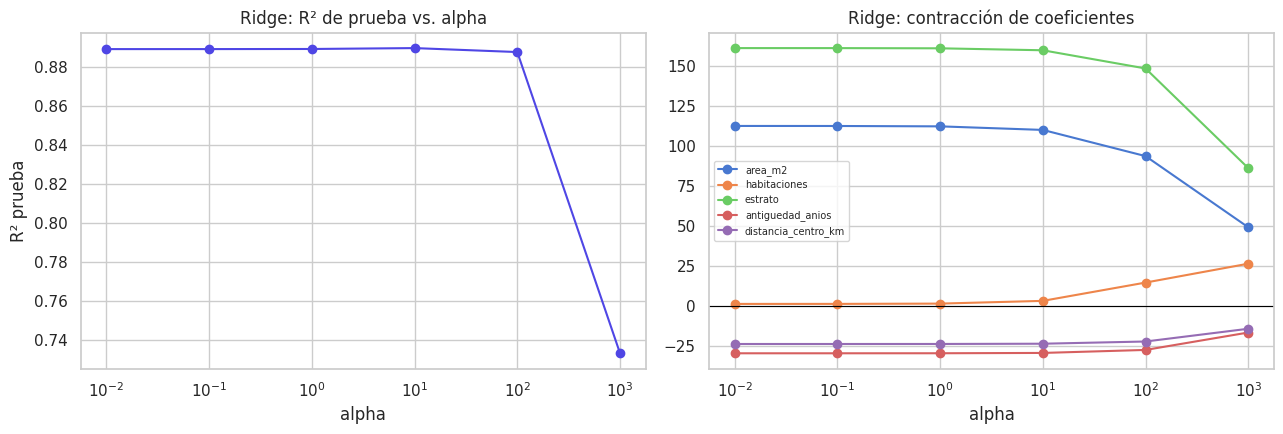

,alpha,area_m2,habitaciones,estrato,antiguedad_anios,distancia_centro_km,R2_test
0,0.0100,112.5951,1.0804,161.3782,-29.8529,-24.0273,0.8894
1,0.1000,112.5719,1.0984,161.3658,-29.8508,-24.0257,0.8894
2,1.0000,112.3402,1.2779,161.2423,-29.8307,-24.0101,0.8894
3,10.0000,110.1069,2.9916,160.0155,-29.6304,-23.8561,0.8899
4,100.0000,93.6944,14.4608,148.6082,-27.7511,-22.4694,0.8879
5,"1,000.0000",49.0798,26.2891,86.1535,-16.8298,-14.4778,0.7333


In [6]:
scaler = StandardScaler().fit(Xtr)
Xtr_s = scaler.transform(Xtr)
Xte_s = scaler.transform(Xte)

alphas_ridge = [0.01, 0.1, 1, 10, 100, 1000]
coefs_ridge = []
r2_ridge = []
for a in alphas_ridge:
    r = Ridge(alpha=a).fit(Xtr_s, ytr)
    coefs_ridge.append(r.coef_)
    r2_ridge.append(r2_score(yte, r.predict(Xte_s)))
coefs_ridge = np.array(coefs_ridge)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(alphas_ridge, r2_ridge, marker="o", color="#4f46e5")
axes[0].set_xscale("log")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("R² prueba")
axes[0].set_title("Ridge: R² de prueba vs. alpha")

for j, f in enumerate(feat_cols):
    axes[1].plot(alphas_ridge, coefs_ridge[:, j], marker="o", label=f)
axes[1].set_xscale("log")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("alpha")
axes[1].set_title("Ridge: contracción de coeficientes")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

tabla_ridge = pd.DataFrame(coefs_ridge, columns=feat_cols)
tabla_ridge.insert(0, "alpha", alphas_ridge)
tabla_ridge["R2_test"] = r2_ridge
display(tabla_ridge.round(4))

**Lectura:** entre `alpha=0.01` y `alpha=100` el $R^2$ de prueba se mantiene prácticamente estable (0.8894-0.8899, con un máximo leve en `alpha=10`) — el modelo es robusto a regularizaciones moderadas porque, como se vio en la Sección 1, no estaba sobreajustando de entrada. Recién en `alpha=1000` (regularización muy fuerte) el $R^2$ cae bruscamente a 0.7333, y los coeficientes se contraen de forma visible: `estrato` pasa de ≈161 (sin regularizar) a 86.15, `area_m2` de ≈112 a 49.08. Ningún coeficiente llega a cero exacto en ningún punto del barrido — la firma característica de Ridge frente a Lasso (Sección 5).

---
## 5. Lasso (L1): Selección Automática de Variables ✂️

Lasso reemplaza la penalización cuadrática de Ridge por el **valor absoluto** de los coeficientes:

$$\min_{w,b} \sum_{i=1}^{N} \big(y_i - (w^Tx_i+b)\big)^2 + \alpha \sum_{j} |w_j|$$

Geométricamente, esta penalización tiene "esquinas" en los ejes que hacen que la solución óptima caiga exactamente sobre ellos con frecuencia — es decir, Lasso puede llevar coeficientes a **cero exacto**, eliminando variables del modelo por completo. Se repite el mismo barrido sobre las variables escaladas de `inmuebles_precios.csv`.

In [7]:
alphas_lasso = [0.001, 0.01, 0.1, 1, 5, 10, 20, 50]
coefs_lasso = []
r2_lasso = []
for a in alphas_lasso:
    l = Lasso(alpha=a, max_iter=20000).fit(Xtr_s, ytr)
    coefs_lasso.append(l.coef_)
    r2_lasso.append(r2_score(yte, l.predict(Xte_s)))
coefs_lasso = np.array(coefs_lasso)

tabla_lasso = pd.DataFrame(coefs_lasso, columns=feat_cols)
tabla_lasso.insert(0, "alpha", alphas_lasso)
tabla_lasso["R2_test"] = r2_lasso
display(tabla_lasso.round(4))

,alpha,area_m2,habitaciones,estrato,antiguedad_anios,distancia_centro_km,R2_test
0,0.0010,112.6019,1.0740,161.3785,-29.8521,-24.0265,0.8894
1,0.0100,112.6111,1.0577,161.3697,-29.8433,-24.0182,0.8894
2,0.1000,112.5678,1.0010,161.2843,-29.7554,-23.9342,0.8895
3,1.0000,112.0940,0.4667,160.4308,-28.8765,-23.0932,0.8904
4,5.0000,108.4704,0.0000,156.6834,-24.9782,-19.3255,0.8926
5,10.0000,103.4905,0.0000,152.0131,-20.1077,-14.6068,0.8910
6,20.0000,93.5307,0.0000,142.6726,-10.3667,-5.1692,0.8732
7,50.0000,63.5314,0.0000,113.1767,-0.0000,-0.0000,0.7718


**Lectura:** a diferencia de Ridge, Lasso **sí anula coeficientes exactamente**: a partir de `alpha=5`, `habitaciones` cae a 0.0 — una variable cuya correlación con `area_m2` (0.796 -- se cuantifica en la Sección 6) la vuelve parcialmente redundante. Sorprendentemente, el $R^2$ de prueba en `alpha=5` (0.8926) es el **mejor de todo el barrido** — ligeramente superior al de OLS sin regularizar (0.8894) — evidencia de que `habitaciones` aportaba más ruido que señal una vez que `area_m2` y `estrato` ya están en el modelo. A partir de `alpha=20` el desempeño empieza a deteriorarse (0.8732), y en `alpha=50` tres de cinco coeficientes ya son cero (`habitaciones`, `antiguedad_anios`, `distancia_centro_km`), con el $R^2$ cayendo a 0.7718 — la regularización ya eliminó variables genuinamente informativas.

---
## 6. ElasticNet: Combinando L1 y L2 🔗

ElasticNet combina ambas penalizaciones con un parámetro de mezcla `l1_ratio` $\in [0,1]$:

$$\min_{w,b} \sum_{i=1}^{N} \big(y_i - (w^Tx_i+b)\big)^2 + \alpha \Big[ \text{l1\_ratio} \cdot \sum_j |w_j| + (1-\text{l1\_ratio}) \cdot \sum_j w_j^2 \Big]$$

`l1_ratio=1` equivale a Lasso puro; `l1_ratio=0` equivale a Ridge puro. La ventaja de ElasticNet aparece con **variables correlacionadas entre sí**: Lasso tiende a escoger arbitrariamente una de dos variables correlacionadas y anular la otra por completo (como ocurrió con `habitaciones` en la Sección 5, correlacionada 0.796 con `area_m2`), mientras que ElasticNet tiende a repartir el peso entre ambas — el llamado *efecto de agrupamiento* (*grouping effect*).

In [8]:
print("Correlacion area_m2 vs. habitaciones:", round(X[["area_m2", "habitaciones"]].corr().iloc[0, 1], 4))

lasso5 = Lasso(alpha=5, max_iter=20000).fit(Xtr_s, ytr)
en5 = ElasticNet(alpha=5, l1_ratio=0.5, max_iter=20000).fit(Xtr_s, ytr)

tabla_grouping = pd.DataFrame({
    "variable": feat_cols,
    "Lasso (alpha=5)": lasso5.coef_,
    "ElasticNet (alpha=5, l1_ratio=0.5)": en5.coef_,
})
display(tabla_grouping.round(4))
print("R2 test Lasso (alpha=5):", round(r2_score(yte, lasso5.predict(Xte_s)), 4))
print("R2 test ElasticNet (alpha=5, l1_ratio=0.5):", round(r2_score(yte, en5.predict(Xte_s)), 4))

Correlacion area_m2 vs. habitaciones: 0.7964


,variable,Lasso (alpha=5),"ElasticNet (alpha=5, l1_ratio=0.5)"
0,area_m2,108.4704,27.6392
1,habitaciones,0.0000,18.0727
2,estrato,156.6834,45.8726
3,antiguedad_anios,-24.9782,-8.6317
4,distancia_centro_km,-19.3255,-7.7132


R2 test Lasso (alpha=5): 0.8926
R2 test ElasticNet (alpha=5, l1_ratio=0.5): 0.484


**Lectura — efecto de agrupamiento:** con `alpha=5`, Lasso anula por completo `habitaciones` (0.0) y concentra el peso en `area_m2` (108.47); ElasticNet con la misma `alpha` pero `l1_ratio=0.5` **conserva ambas variables** (`area_m2`=27.64, `habitaciones`=18.07), repartiendo entre las dos correlacionadas en lugar de escoger una arbitrariamente — el efecto de agrupamiento en acción. La contrapartida es que, a esta combinación concreta de `alpha` y `l1_ratio` (no ajustada por validación cruzada, solo elegida para ilustrar el efecto), el $R^2$ de prueba de ElasticNet (0.4840) es notablemente peor que el de Lasso (0.8926): al combinar ambas penalizaciones con `alpha=5`, la componente L2 contrae *todos* los coeficientes con más fuerza de la necesaria. En la práctica, `alpha` y `l1_ratio` deben ajustarse mediante validación cruzada (`ElasticNetCV`, análogo a `RidgeCV`/`LassoCV` de la Sección 7) — este ejemplo es puramente ilustrativo del comportamiento cualitativo, no de qué configuración usar en producción.

### 6.1 Tabla Comparativa: OLS vs. Ridge vs. Lasso vs. ElasticNet

| Método | Penalización | Efecto sobre coeficientes | Cuándo preferirlo |
|---|---|---|---|
| **OLS** (`LinearRegression`) | Ninguna | Sin restricción — puede sobreajustar con muchas variables o poca información. | Pocas variables, ya razonablemente informativas, sin fuerte colinealidad (Sección 1: $R^2$ train≈test≈0.89). |
| **Ridge** (L2) | $\alpha\sum w_j^2$ | Contrae todos los coeficientes suavemente hacia cero, nunca exactamente. | Se sospecha que **todas** las variables aportan algo; hay multicolinealidad y se prioriza estabilidad numérica. |
| **Lasso** (L1) | $\alpha\sum \lvert w_j \rvert$ | Puede anular coeficientes exactamente — selección automática de variables. | Se sospecha que **algunas** variables son irrelevantes o redundantes y se busca un modelo más simple/interpretable (Sección 5: `habitaciones` anulada). |
| **ElasticNet** (L1+L2) | Combinación ponderada por `l1_ratio` | Puede anular coeficientes, pero reparte el peso entre variables correlacionadas (efecto de agrupamiento). | Hay grupos de variables **correlacionadas entre sí** (aquí, `area_m2` y `habitaciones`, r=0.796) y se quiere evitar que Lasso descarte una de forma arbitraria. |

---
## 7. Selección Automática de `alpha`: `RidgeCV` y `LassoCV` 🔄

Los barridos manuales de las Secciones 4-5 evaluaron el desempeño **sobre el propio conjunto de prueba** — en rigor, eso es "espiar" el conjunto de prueba para elegir un hiperparámetro, el mismo problema de fondo que motivó la validación cruzada en el Cuaderno 00. `RidgeCV` y `LassoCV` resuelven esto internamente: prueban una rejilla de valores de `alpha` usando **validación cruzada k-fold sobre el conjunto de entrenamiento únicamente**, y se quedan con el que minimiza el error promedio — el conjunto de prueba se reserva, sin tocar, para la evaluación final.

In [9]:
ridgecv = RidgeCV(alphas=np.logspace(-3, 3, 50)).fit(Xtr_s, ytr)
print("RidgeCV -- mejor alpha:", round(ridgecv.alpha_, 4))
print("RidgeCV -- R2 prueba:", round(r2_score(yte, ridgecv.predict(Xte_s)), 4))

lassocv = LassoCV(alphas=np.logspace(-3, 2, 50), max_iter=20000, random_state=42, n_jobs=1).fit(Xtr_s, ytr)
print("\nLassoCV -- mejor alpha:", round(lassocv.alpha_, 4))
print("LassoCV -- R2 prueba:", round(r2_score(yte, lassocv.predict(Xte_s)), 4))
print("LassoCV -- coeficientes:", dict(zip(feat_cols, np.round(lassocv.coef_, 4))))

RidgeCV -- mejor alpha: 0.6551
RidgeCV -- R2 prueba: 0.8894

LassoCV -- mejor alpha: 0.569
LassoCV -- R2 prueba: 0.89
LassoCV -- coeficientes: {'area_m2': np.float64(112.32), 'habitaciones': np.float64(0.7232), 'estrato': np.float64(160.8396), 'antiguedad_anios': np.float64(-29.2974), 'distancia_centro_km': np.float64(-23.4959)}


**Lectura:** `RidgeCV` selecciona `alpha≈0.6551` mediante validación cruzada, con un $R^2$ de prueba (0.8894) prácticamente idéntico al de OLS sin regularizar — consistente con la Sección 4, donde ya se observó que este dataset apenas se beneficia de Ridge. `LassoCV` selecciona `alpha≈0.5690`, un valor **muy por debajo** del `alpha=5` que en la Sección 5 anulaba `habitaciones`: a este nivel de regularización, ningún coeficiente llega a cero (los 5 permanecen no nulos, con valores muy cercanos a los de OLS), y el $R^2$ de prueba (0.8900) es apenas superior al de OLS. La validación cruzada confirma, de forma automática y sin tocar el conjunto de prueba, lo que los barridos manuales ya sugerían: este dataset de 5 variables no está sobreajustado y solo necesita una regularización muy ligera.

---
## 8. Ejercicio Práctico Guiado: Features Polinomiales + `LassoCV` 📝

**Contexto:** la Sección 3 mostró que un polinomio de grado alto sobre una sola variable (`area_m2`) sobreajusta. Pero cuando se combinan **varias** variables con `PolynomialFeatures(degree=2)`, se generan también términos de **interacción** (p. ej. `area_m2 × estrato`) que pueden capturar relaciones que ningún término individual captura solo — y Lasso, dentro de ese conjunto ampliado de variables, puede identificar automáticamente cuáles términos aportan.

**Tu misión:**
1. Genera las variables polinomiales de grado 2 (`PolynomialFeatures(degree=2, include_bias=False)`) a partir de `Xtr` y `Xte` (las 5 variables originales de `inmuebles_precios.csv`).
2. Escala esas variables polinomiales con `StandardScaler` (ajustado solo sobre el conjunto de entrenamiento transformado).
3. Ajusta `LassoCV(alphas=np.logspace(-3, 2, 20), max_iter=20000, random_state=42, cv=5, n_jobs=1)` sobre los datos polinomiales escalados de entrenamiento.
4. Calcula el $R^2$ de prueba y compáralo con el 0.8894 de OLS (Sección 1, solo variables originales).
5. Cuenta cuántos de los coeficientes son exactamente cero, y con `poly.get_feature_names_out(feat_cols)` identifica cuáles términos fueron anulados.

In [10]:
### TU CÓDIGO AQUÍ ###
# 1. Genera las features polinomiales de grado 2
poly2 = None
Xtr_poly = None
Xte_poly = None

# 2. Escala las features polinomiales
scaler_poly = None
Xtr_poly_s = None
Xte_poly_s = None

# 3. Ajusta LassoCV
lassocv_poly = None

# 4. R2 de prueba
r2_poly_cv = None
print("R2 prueba (polinomial + LassoCV):", r2_poly_cv)

# 5. Coeficientes en cero y sus nombres
n_nonzero = None
nombres_poly = None
zeroed = None
print("Coeficientes distintos de cero:", n_nonzero)
print("Terminos anulados:", zeroed)

R2 prueba (polinomial + LassoCV): None
Coeficientes distintos de cero: None
Terminos anulados: None


<details>
<summary>💡 Ver solución propuesta</summary>

```python
poly2 = PolynomialFeatures(degree=2, include_bias=False)
Xtr_poly = poly2.fit_transform(Xtr)
Xte_poly = poly2.transform(Xte)

scaler_poly = StandardScaler().fit(Xtr_poly)
Xtr_poly_s = scaler_poly.transform(Xtr_poly)
Xte_poly_s = scaler_poly.transform(Xte_poly)

lassocv_poly = LassoCV(alphas=np.logspace(-3, 2, 20), max_iter=20000, random_state=42, cv=5, n_jobs=1).fit(Xtr_poly_s, ytr)

r2_poly_cv = r2_score(yte, lassocv_poly.predict(Xte_poly_s))
print("R2 prueba (polinomial + LassoCV):", r2_poly_cv)

n_nonzero = int((np.abs(lassocv_poly.coef_) > 1e-8).sum())
nombres_poly = poly2.get_feature_names_out(feat_cols)
zeroed = [n for n, c in zip(nombres_poly, lassocv_poly.coef_) if abs(c) < 1e-8]
print("Coeficientes distintos de cero:", n_nonzero, "de", Xtr_poly.shape[1])
print("Terminos anulados:", zeroed)
```

</details>

---
## 9. Resumen Ejecutivo del Cuaderno 03 📌

1. **OLS explica el 88.94% de la varianza de `precio_millones` en prueba** con solo 5 variables (RMSE≈62.96 millones), con coeficientes que se interpretan **directamente** como efectos marginales en millones de pesos (`+3.91` millones por m², `+136.12` millones por estrato) — a diferencia de los odds ratios multiplicativos del Cuaderno 02.
2. **El gráfico de residuos reveló heterocedasticidad leve y asimetría positiva** (correlación $\lvert$residuo$\rvert$-predicho = 0.1456, skew = 1.4667): el modelo tiende a subestimar los inmuebles más caros con más frecuencia de lo que los sobreestima, sin que esto invalide el modelo.
3. **La regresión polinomial ilustró el sobreajuste de forma medible:** sobre `area_m2` en solitario, el $R^2$ de entrenamiento sube de forma monótona con el grado (0.2809 → 0.2898, grados 1 a 30), mientras que el de prueba alcanza su máximo en grado 6 (0.2805) y luego cae a 0.2234 en grado 30 — la misma brecha train-test creciente del dilema sesgo-varianza (Cuaderno 00).
4. **Ridge contrae los coeficientes suavemente sin anularlos** (poco efecto hasta `alpha=100`, colapso solo en `alpha=1000`); **Lasso sí anula coeficientes exactos** (`habitaciones` en `alpha≥5`), incluso mejorando el $R^2$ de prueba a 0.8926 al descartar una variable redundante.
5. **ElasticNet reparte el peso entre variables correlacionadas** (`area_m2` y `habitaciones`, r=0.796) en lugar de escoger una arbitrariamente como hace Lasso — el efecto de agrupamiento, útil quirúrgicamente cuando hay grupos de variables correlacionadas, aunque su desempeño depende críticamente de ajustar bien `alpha` y `l1_ratio`.
6. **`RidgeCV`/`LassoCV` seleccionan `alpha` por validación cruzada sin tocar el conjunto de prueba** (Cuaderno 00): en este dataset, ambos convergen a regularizaciones ligeras (`alpha≈0.66` y `alpha≈0.57` respectivamente), confirmando que el modelo de 5 variables ya generalizaba bien de partida.
7. **Siguiente paso:** el **Cuaderno 04** cierra el módulo con las métricas de evaluación rigurosas para clasificación (matriz de confusión, precisión, recall, F1, ROC-AUC) y regresión (RMSE, MAE, R²) que se han ido postergando a lo largo de los Cuadernos 01-03.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | Clasificación y Regresión</i>
  </p>
</div>